# Clifford Annealing Qubit Hamiltonians

Given some initial hamiltonian $\mathcal{H}_{q} = \mathcal{E}(\mathcal{H}_{f})$ expressed in terms of Pauli operators we can apply Clifford gates to transform to another hamiltonian $\mathcal{H}_{q}\to C^{\dagger}\mathcal{H}_{q}C$. This is equivalent to applying a different encoding.

The underlying optimisation is based on simulated annealing. Together with an initial hamiltonian, we initialise a Clifford operator $ B=\hat{I} $. The procedure continues iteratively:

Clifford operators are sampled randomly from the set: 

$$ \{CNOT_{i,j}H_{i},\ CNOT_{i,j}S_{i},\ CNOT_{i,j},  | i\neq j\} $$

With each iteration we sample a single operator $D$ and evaluate the change in the cost function. 

$$ \Delta = C[D^{\dagger}B H BD]-C[BHB] $$

The operator is updated $B \gets BD$ with probability 

$$ e^{-\beta(t)\Delta} $$

where $\beta(t)$ is the temperature schedule at time $t$, including a term $\Theta$ which enforces complete randomness before a minimum time. 

$$ \beta(t)=\log(c_{1}+c_{2}t) \frac{c_{3}}{C(B)} \Theta(t-t_{min}) $$

In `ferrmion`, the setup is slightly different, but the logic of applying simulated annealing to update an encoded hamiltonian is the same. See the `core` docs for details.

In [1]:
import ferrmion as fr
import numpy as np
from nbutils import get_naive_result,get_permuation_results, get_water_data, get_topphatt_result, pauli_weights
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def get_clifford_heuristic_result(tree,fham,coef_weight, temperature=1, n_seeds=10, clifford_subset=None):
    print(f"Getting Clifford Heuristic results ({n_seeds} seeds, coef_weight={coef_weight})...")
    sdmeans = {"unscaled": [], "scaled": [], "length": []}
    for seed in range(n_seeds):
        # To avoid re-annealing between weighted and unweighted (and across seeds)
        qham: fr.QubitHamiltonian = tree.encode(fham)
        qham = qham.clifford_heuristic(coefficient_weighted=coef_weight, seed=seed * np.random.randint(1,101), temperature=temperature, clifford_subset=clifford_subset)
        result = pauli_weights(qham)
        sdmeans["unscaled"].append(result[0])
        sdmeans["scaled"].append(result[1])
        sdmeans["length"].append(result[2])
    return sdmeans

In [2]:
def get_ch_results(
    tree: fr.TernaryTree, fham:fr.FermionHamiltonian, limit=1000, with_topphatt=False, clifford_subset="C", temperature=1
):
    encoding = tree
    if with_topphatt:
        encoding = tree.topphatt(fham)
        
    sdmeans_naive = get_naive_result(encoding, fham)
    sdmeans = get_permuation_results(encoding, fham, limit)

    sdmeans_clifford_pw = get_clifford_heuristic_result(encoding, fham, False, clifford_subset=clifford_subset, temperature=temperature)
    sdmeans_clifford_cpw = get_clifford_heuristic_result(encoding, fham, True, clifford_subset=clifford_subset, temperature=temperature)

    fig, ax = plt.subplots(layout="constrained")

    ax.scatter(
        sdmeans["unscaled"],
        sdmeans["scaled"],
        label=f"{limit} Random Permutations",
        marker=".",
        color="tab:grey",
        alpha=0.7,
    )
    ax.plot(
        sdmeans_naive["unscaled"],
        sdmeans_naive["scaled"],
        marker="D",
        color="tab:red",
        mec="k",
        markersize=8,
    )
    ax.plot(sdmeans_clifford_pw["unscaled"], sdmeans_clifford_pw["scaled"], marker="P", linestyle="", color="tab:orange", markersize=6)
    ax.plot(sdmeans_clifford_cpw["unscaled"], sdmeans_clifford_cpw["scaled"], marker="X", linestyle="", color="tab:orange", markersize=6)

    # where some data has already been plotted to ax
    handles, labels = plt.gca().get_legend_handles_labels()
    # manually define a new patch
    naive_legend = mlines.Line2D(
        [],
        [],
        label="Naive Enumeration",
        marker="D",
        linestyle="",
        color="tab:red",
        mec="k",
        markersize=8,
    )
    annealed_pw_legend = mlines.Line2D(
        [],
        [],
        label="$W_{P}$ Annealed (10 seeds)",
        marker="P",
        linestyle="",
        color="tab:orange",
        markersize=6,
    )
    annealed_cpw_legend = mlines.Line2D(
        [],
        [],
        label="$W_{CP}$ Annealed (10 seeds)",
        marker="X",
        linestyle="",
        color="tab:orange",
        markersize=6,
    )
    topphatt_legend = mlines.Line2D(
        [],
        [],
        label="TOPP-HATT",
        marker="D",
        linestyle="",
        color="tab:red",
        mec="k",
        markersize=8,
    )

    data = {
        "random": sdmeans,
        "naive": sdmeans_naive,
        "annealed_pw":sdmeans_clifford_pw,
        "annealed_cpw":sdmeans_clifford_cpw,
    }

    # handles is a list, so append manual patch
    if with_topphatt:
        handles.extend([topphatt_legend])
    else:
        handles.extend([naive_legend])

    handles.extend(
        [
            annealed_pw_legend,
            annealed_cpw_legend,
        ]
    )


    ax.set_xlabel("unscaled pauli-weight")
    ax.set_ylabel("coefficient scaled pauli-weight")
    ax.set_title(f"Jordan-Wigner Encodings of $H_2 O$:$6-31G$")
    fig.legend(handles=handles, loc="outside lower center", ncols=len(handles) // 2)
    fig.show()

# Example

Let's start with the Jordan-Wigner encoded hamiltonian of the water molecule in $6-31G$ basis.

We'll show a distribution of random enumerations of JW, the naive encoding and results of Clifford annealing which begins at the Naive enumeration.

Getting Naive result...
Naive result: (285512, 2342.1167270604456, 23328)
Getting 1000 random results...
Permutation Results
Getting Clifford Heuristic results (10 seeds, coef_weight=False)...
Getting Clifford Heuristic results (10 seeds, coef_weight=True)...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_12780/3964463124.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


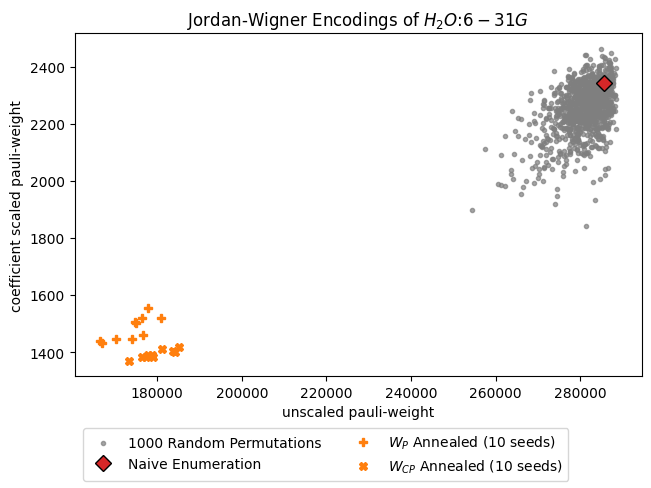

In [3]:
ones, twos, enuc = get_water_data()
fham = fr.molecular_hamiltonian(ones, twos, enuc)
tree = fr.JordanWigner(fham.n_modes)
get_ch_results(tree, fham)

## Pairing with TOPP-HATT

Since the method takes any input Pauli Hamiltonian, we can start with one that has been optimised by another method.

Generally the results for the Jordan Wigner encoding are significantly improved by using TOPP-HATT first.

As a nice bonus, simulated annealing converges more quickly, meaning TOPP-HATT *reduces the run time*.

Getting Naive result...
Naive result: (214156, 1480.8662101680088, 23328)
Getting 1000 random results...
Permutation Results
Getting Clifford Heuristic results (10 seeds, coef_weight=False)...
Getting Clifford Heuristic results (10 seeds, coef_weight=True)...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_12780/3964463124.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


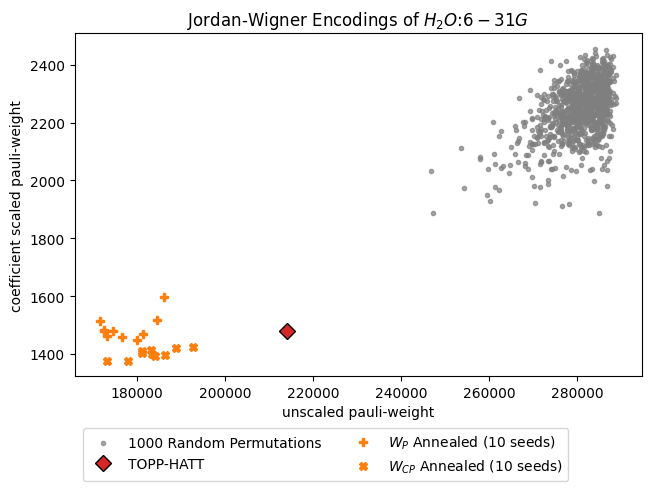

In [4]:
tree = fr.JordanWigner(fham.n_modes)
get_ch_results(tree, fham, with_topphatt=True)

# Randomised Subsystem Descent

The downside of the clifford heuristic method is that the computation time increases rapidly with the system size.

One option for improving on this is RSD, which iteratively applies the clifford method on subsets of qubits.
This means you to get clever with how you choose those subsystems.

The available samplers are:
- "full_system" - Use the full system (equivalent to running the normal Clifford Heuristic method).
- "uniform" - Uniform sampling across all qubits
- "hamming" - Sample according to total Hamming weight of each qubit.

Within the rust `core`, you can also pass your own function to perform sampling.

Let's see how this work by overwriting the helper function we wrote above.

In [5]:
def get_clifford_heuristic_result(tree,fham,coef_weight,clifford_subset, temperature=1, n_seeds=10):
    print(f"Getting Clifford Heuristic results ({n_seeds} seeds, coef_weight={coef_weight})...")
    sdmeans = {"unscaled": [], "scaled": [], "length": []}
    for seed in range(n_seeds):
        # To avoid re-annealing between weighted and unweighted (and across seeds)
        qham: fr.QubitHamiltonian = tree.encode(fham)
        qham = qham.randomised_subsystem_descent(iterations=100, subsystem_dimension=qham.n_qubits//2, coefficient_weighted=coef_weight, seed=seed * np.random.randint(1,101), temperature=temperature, sampler="hamming", clifford_subset=clifford_subset)
        result = pauli_weights(qham)
        sdmeans["unscaled"].append(result[0])
        sdmeans["scaled"].append(result[1])
        sdmeans["length"].append(result[2])
    return sdmeans

Getting Naive result...
Naive result: (285512, 2342.1167270604456, 23328)
Getting 1000 random results...
Permutation Results
Getting Clifford Heuristic results (10 seeds, coef_weight=False)...
Getting Clifford Heuristic results (10 seeds, coef_weight=True)...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_12780/3964463124.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


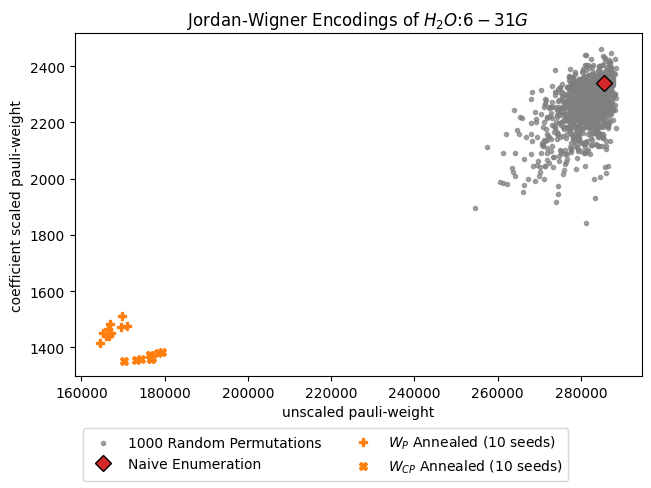

In [6]:
tree = fr.JordanWigner(fham.n_modes)
get_ch_results(tree, fham)

Getting Naive result...
Naive result: (214156, 1480.8662101680088, 23328)
Getting 1000 random results...
Permutation Results
Getting Clifford Heuristic results (10 seeds, coef_weight=False)...
Getting Clifford Heuristic results (10 seeds, coef_weight=True)...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_12780/3964463124.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


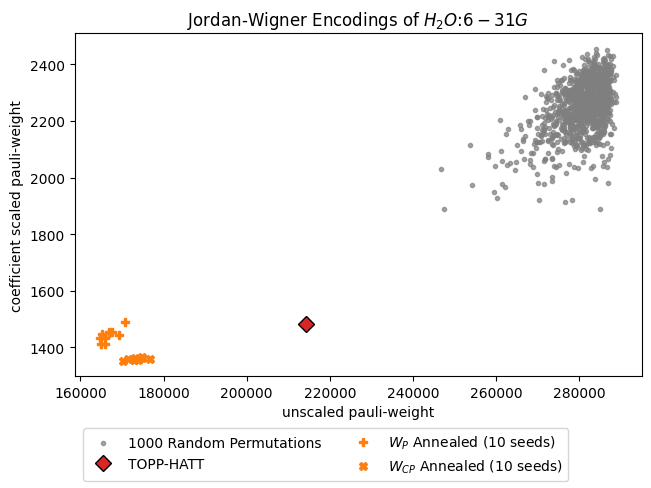

In [7]:
tree = fr.JordanWigner(fham.n_modes)
get_ch_results(tree, fham, with_topphatt=True)

# Clifford Operator Subsets

You can also choose which Clifford operators to sample from during optimisation. The options are:
- "C" - $\{CNOT_{i,j}\}$
- "CH" - $\{CNOT_{i,j}H_{i}\}$
- "CS" - $\{CNOT_{i,j}S_{i}\}$
- "CHS" - $\{CNOT_{i,j}H_{i}, CNOT_{i,j}S_{i}\}$
- "all" - $\{H_{i}, S_{i}, CNOT_{i,j}\}$

Note that only the CNOT gate will change the Pauli-weight of the Hamiltonian.

Getting Naive result...
Naive result: (214156, 1480.8662101680088, 23328)
Getting 1000 random results...
Permutation Results
Getting Clifford Heuristic results (10 seeds, coef_weight=False)...
Getting Clifford Heuristic results (10 seeds, coef_weight=True)...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_12780/3964463124.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


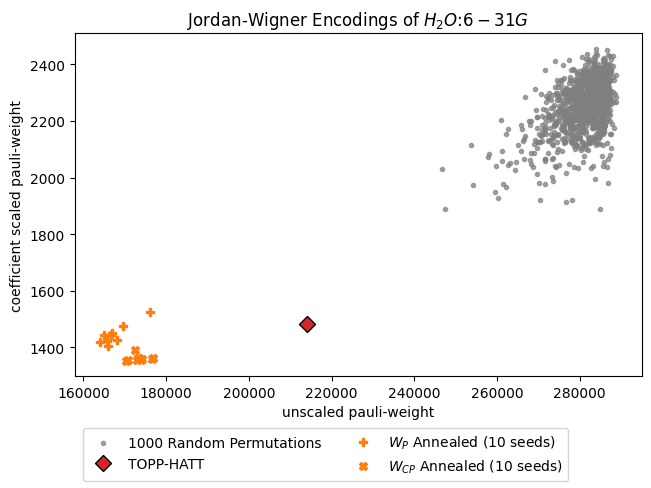

In [8]:
tree = fr.JordanWigner(fham.n_modes)
get_ch_results(tree, fham, with_topphatt=True, clifford_subset="C")